Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Select the event:
0 - Noto, Mw 7.5 (01.01.2024)
1 - Gulf of Alaska, Mw 7.9 (23.01.2018)
2 - Kamchatka, Mw 8.8 (29.07.2025)
3 - Chignik, Mw 8.2 (29.07.2021)
1
Computed b for station S2N17 on GPU
Computed b for station S2N18 on GPU
Computed b for station S4N06 on GPU
Computed b for station S4N11 on GPU
Computed b for station S4N25 on GPU
Computed b for station S6N08 on GPU


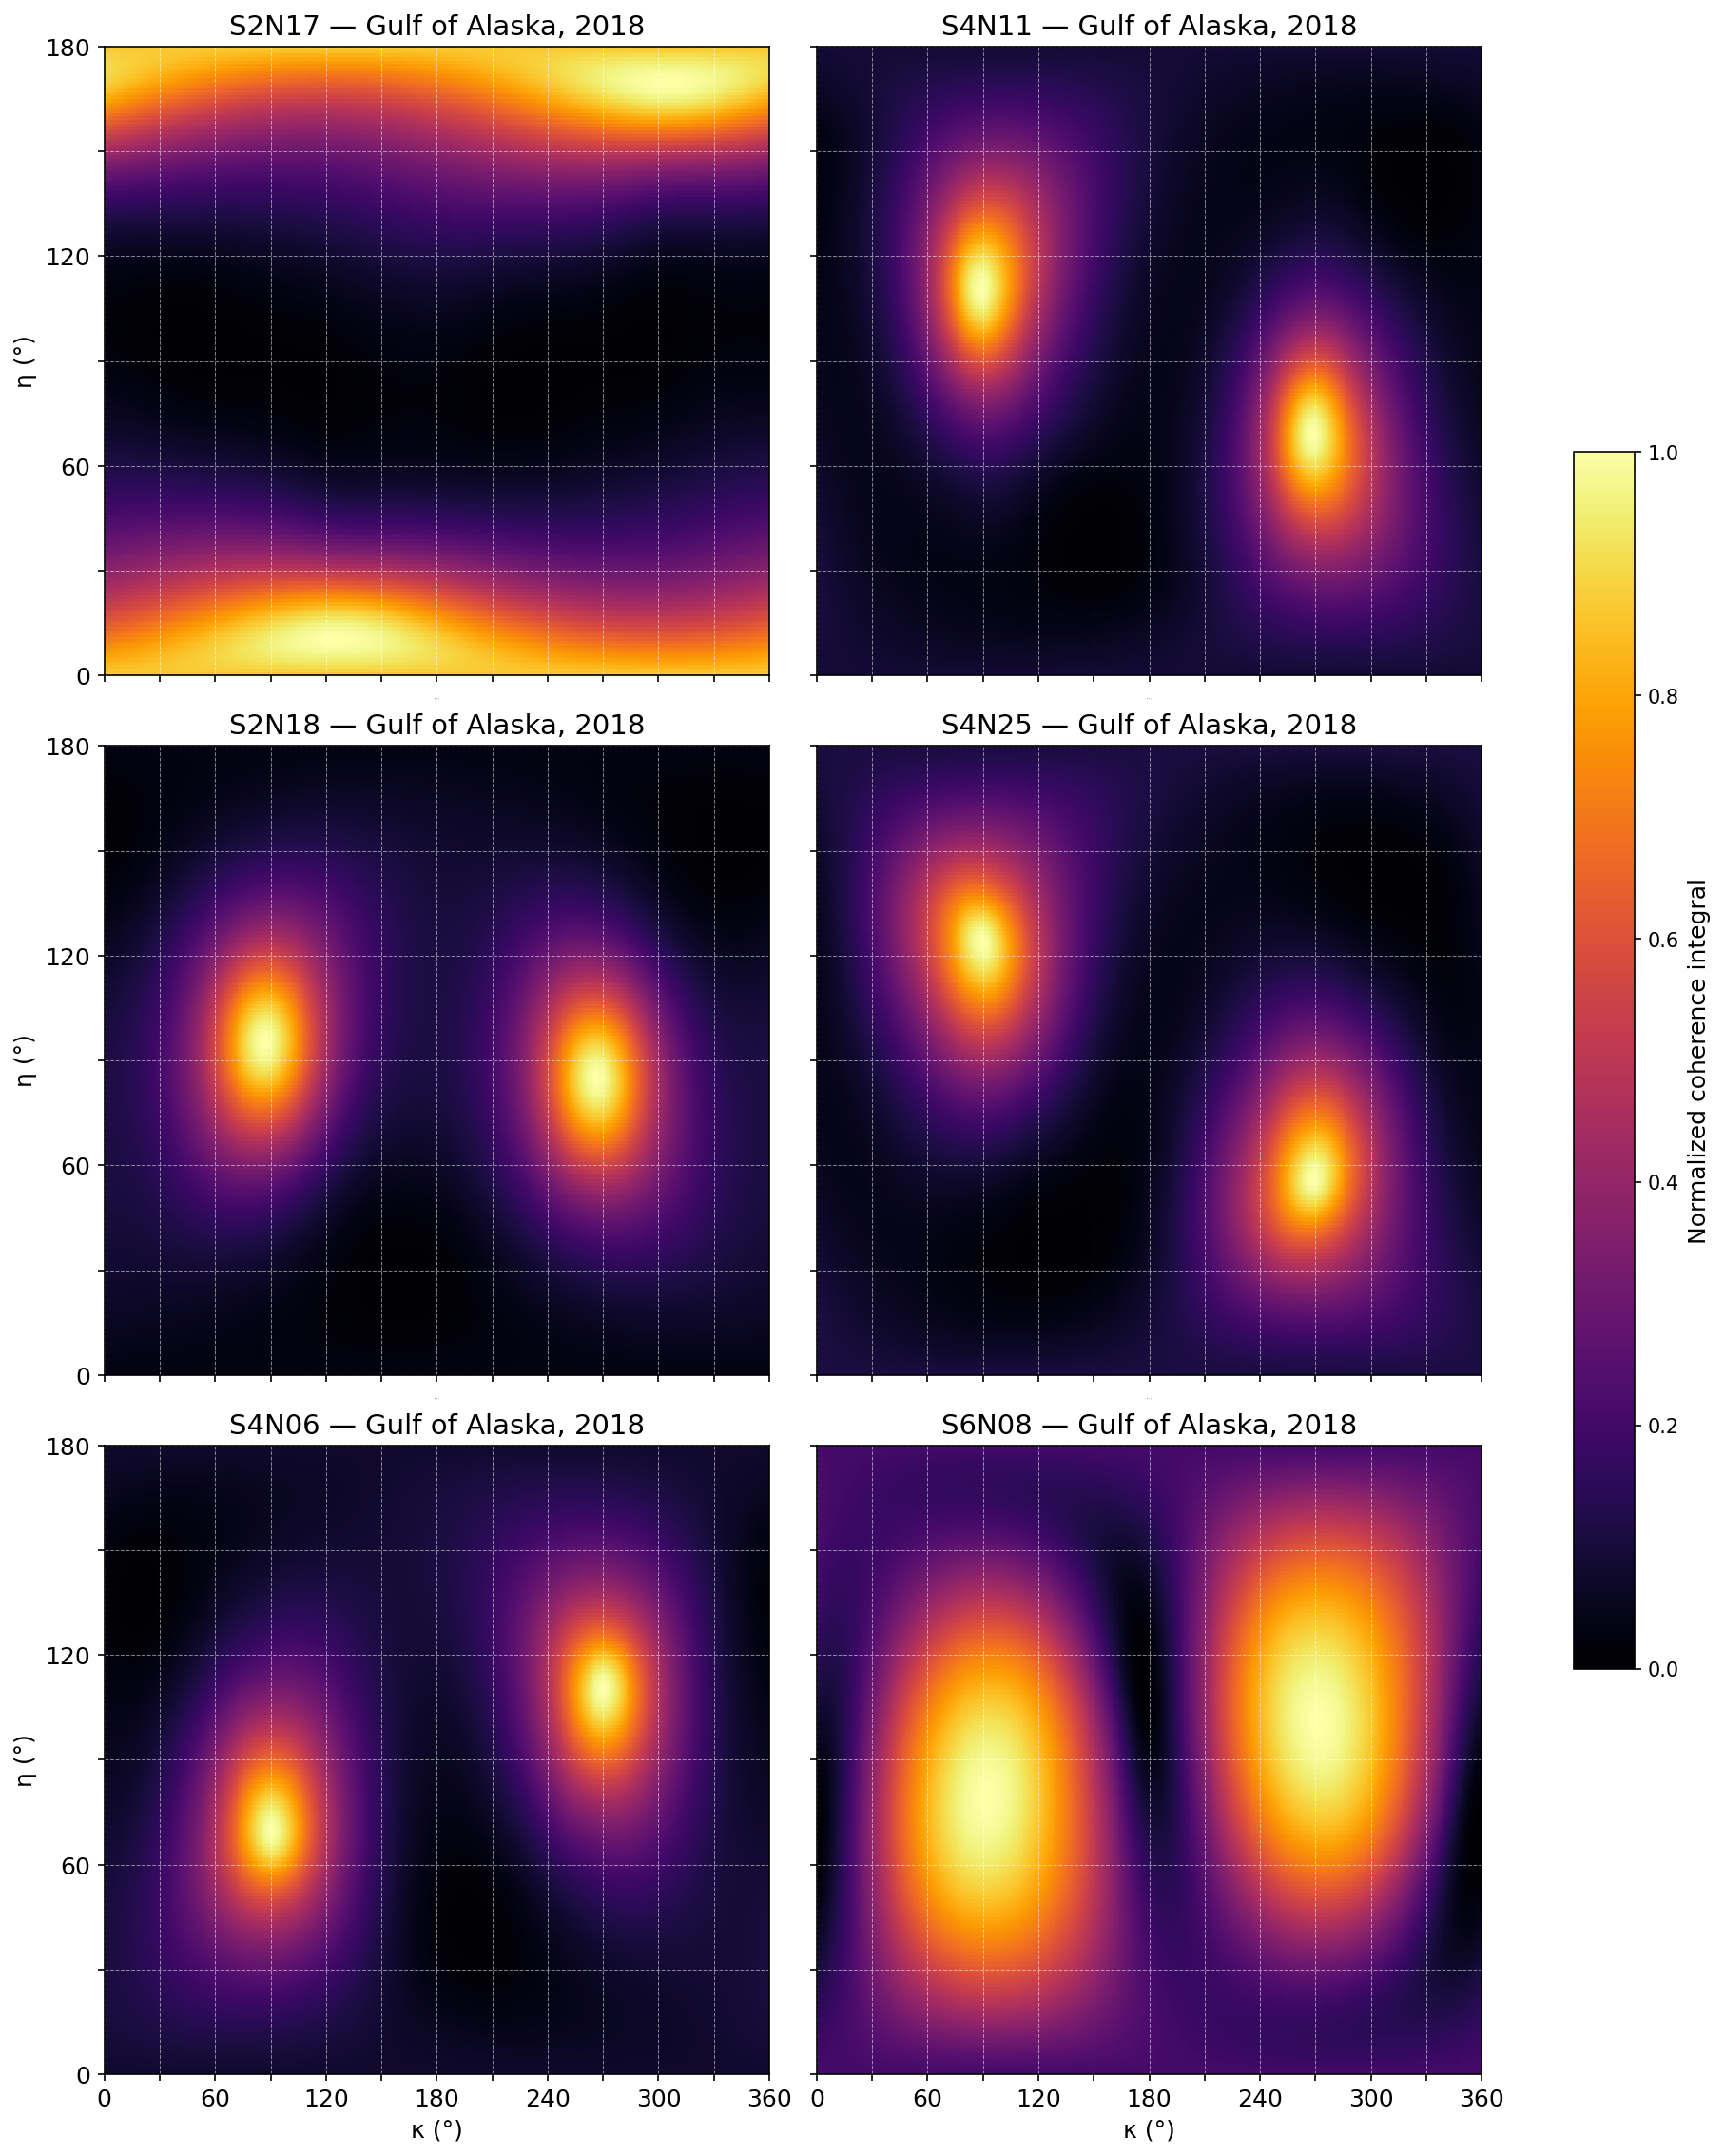

Time: 77.43 seconds
Saved: event1_grid.png


In [13]:
import time

from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

try:
    import cupy as cp
except ImportError as e:
    raise ImportError(
        "CuPy not found. Download for your CUDA:\n"
        "pip install cupy-cuda12x\n"
    ) from e

################## DO NOT CHANGE IF NOT SURE WHAT YOU ARE DOING ################
nperseg = 2**13
fs = 10.0
step = nperseg // 2
################################################################################


thetres = 180 # Resolution by eta (180 => one point per 1 degree)
phires = thetres*2  # Resolution by kappa (normally should be x2 from eta)
batch_size = 256 # increase to make faster, lower if fails


print('Select the event:')
print('0 - Noto, Mw 7.5 (01.01.2024)')
print('1 - Gulf of Alaska, Mw 7.9 (23.01.2018)')
print('2 - Kamchatka, Mw 8.8 (29.07.2025)')
print('3 - Chignik, Mw 8.2 (29.07.2021)')
event_index = int(input())
start_time = time.time()

# If you want to use other stations, you have to replace all their data here manually. Good luck.
stations = [
    [r'/S2N17', 'e30e', 'e302', '2247', '0.04893', '0.04792', '0.04923', 'e300', 'e301'],
    [r'/S2N18', 'e31e', 'e312', '2460', '0.04878', '0.04930', '0.04885', 'e310', 'e311'],
    [r'/S4N06', 'e65c', 'e652', '1970', '0.04874', '0.04863', '0.04856', 'e650', 'e651'],
    [r'/S4N11', 'e6ae', 'e6a2', '2273', '0.04829', '0.04818', '0.04912', 'e6a0', 'e6a1'],
    [r'/S4N25', 'e78e', 'e782', '2228', '0.04792', '0.04811', '0.04729', 'e780', 'e781'],
    [r'/S6N08', 'ea7e', 'ea72', '5900', '0.05205', '0.05182', '0.05178', 'ea70', 'ea71'],
]

eventsp = [
    r'/content/drive/MyDrive/data/pressure/Noto/',
    r'/content/drive/MyDrive/data/pressure/Gulf/',
    r'/content/drive/MyDrive/data/pressure/Kamchatka/',
    r'/content/drive/MyDrive/data/pressure/Chignik/'
]
eventsac = [
    r'/content/drive/MyDrive/data/acceleration/Noto/',
    r'/content/drive/MyDrive/data/acceleration/Gulf/',
    r'/content/drive/MyDrive/data/acceleration/Kamchatka/',
    r'/content/drive/MyDrive/data/acceleration/Chignik/'
]



event_title_map = {
    0: 'Noto, 2024',
    1: 'Gulf of Alaska, 2018',
    2: 'Kamchatka, 2025',
    3: 'Chignik, 2021'
}
event_title = event_title_map.get(event_index, f'Event {event_index}')


th = np.linspace(0, 180, thetres, dtype=np.float32)
ph = np.linspace(0, 360, phires, dtype=np.float32)

theta_grid, phi_grid = np.meshgrid(th, ph, indexing='ij')
theta_flat = theta_grid.ravel()
phi_flat = phi_grid.ravel()

ct_all = np.cos(np.deg2rad(theta_flat)).astype(np.float32)
st_all = np.sin(np.deg2rad(theta_flat)).astype(np.float32)
cphi_all = np.cos(np.deg2rad(phi_flat)).astype(np.float32)
sphi_all = np.sin(np.deg2rad(phi_flat)).astype(np.float32)


def build_welch_cache_gpu(ref_signal_gpu, fs, nperseg):

    """
    Precomputes FFT for the reference signal using Welch windows.
    Returns:
      starts: list of window start indices
      Xf: FFT of reference signal windows, shape (nseg, nfreq)
      Pxx: averaged power spectrum of the reference signal
      freqs: rFFT frequencies
      win: Hann window
    """

    n = int(ref_signal_gpu.size)
    if n < nperseg:
        return None

    starts = list(range(0, n - nperseg + 1, step))
    win = cp.hanning(nperseg).astype(cp.float32)

    x_segs = cp.stack([ref_signal_gpu[s:s + nperseg] for s in starts], axis=0)
    x_segs = x_segs - x_segs.mean(axis=1, keepdims=True)
    x_segs = x_segs * win[None, :]

    Xf = cp.fft.rfft(x_segs, axis=1)
    Pxx = cp.mean(cp.abs(Xf) ** 2, axis=0)
    freqs = cp.fft.rfftfreq(nperseg, d=1.0 / fs)

    return {
        "starts": starts,
        "win": win,
        "Xf": Xf,
        "Pxx": Pxx,
        "freqs": freqs,
    }


def coherence_integral_batch_gpu(cache, ref_signal_gpu, y_batch_gpu, freq_idx):
    """
    Computes the coherence integral for a batch of signals y_batch_gpu.
    y_batch_gpu: shape (B, N)
    Returns: shape (B,)
    """
    starts = cache["starts"]
    win = cache["win"]
    Xf = cache["Xf"]
    Pxx = cache["Pxx"]

    y_segs = cp.stack([y_batch_gpu[:, s:s + nperseg] for s in starts], axis=1)
    y_segs = y_segs - y_segs.mean(axis=2, keepdims=True)
    y_segs = y_segs * win[None, None, :]

    Yf = cp.fft.rfft(y_segs, axis=2)
    Pyy = cp.mean(cp.abs(Yf) ** 2, axis=1)
    Pxy = cp.mean(cp.conj(Xf)[None, :, :] * Yf, axis=1)

    coh = cp.abs(Pxy) ** 2 / (Pxx[None, :] * Pyy + 1e-30)
    return cp.sum(coh[:, freq_idx], axis=1)


def compute_b_gpu_for_station(data_arr, data2, datax, datay, st, batch_size=64):
    """
    Computes the b-matrix for one station with GPU
    """

    pres_g = cp.asarray(np.asarray(data_arr, dtype=np.float32))
    z_g = cp.asarray(np.asarray(data2, dtype=np.float32))
    x_g = cp.asarray(np.asarray(datax, dtype=np.float32))
    y_g = cp.asarray(np.asarray(datay, dtype=np.float32))


    L = min(pres_g.size, z_g.size, x_g.size, y_g.size)
    if L < nperseg:
        return np.zeros((thetres, phires), dtype=np.float32)

    pres_g = pres_g[:L]
    z_g = z_g[:L]
    x_g = x_g[:L]
    y_g = y_g[:L]


    cache = build_welch_cache_gpu(pres_g, fs=fs, nperseg=nperseg)
    if cache is None:
        return np.zeros((thetres, phires), dtype=np.float32)

    fmin = 0.366 * math.sqrt(9.8 / float(st[3]))
    fmax = max(0.1, 1500.0 / (4.0 * float(st[3])))

    freq_idx = cp.where((cache["freqs"] > fmin) & (cache["freqs"] < fmax))[0]
    if int(freq_idx.size) == 0:
        return np.zeros((thetres, phires), dtype=np.float32)

    b_flat = np.empty(theta_flat.size, dtype=np.float32)


    for start in range(0, theta_flat.size, batch_size):
        end = min(start + batch_size, theta_flat.size)

        ct = cp.asarray(ct_all[start:end])
        stv = cp.asarray(st_all[start:end])
        cphi = cp.asarray(cphi_all[start:end])
        sphi = cp.asarray(sphi_all[start:end])

        # batch of projected signals: shape (B, L)
        z_batch = (
            ct[:, None] * z_g[None, :] +
            stv[:, None] * (
                sphi[:, None] * y_g[None, :] +
                cphi[:, None] * x_g[None, :]
            )
        )

        integrals_gpu = coherence_integral_batch_gpu(
            cache=cache,
            ref_signal_gpu=pres_g,
            y_batch_gpu=z_batch,
            freq_idx=freq_idx
        )

        b_flat[start:end] = cp.asnumpy(integrals_gpu)

    return b_flat.reshape(thetres, phires)


# ------------------- main cycle -------------------
b_list = []
station_names = []
valid_indices = []

for idx, st in enumerate(stations):
    station_name = st[0][1:]
    station_names.append(station_name)

    pres_path = eventsp[event_index] + st[1] + '.dat'
    acc_vert_path = eventsac[event_index] + st[2] + '.dat'
    acc_x_path = eventsac[event_index] + st[7] + '.dat'
    acc_y_path = eventsac[event_index] + st[8] + '.dat'

    if not (os.path.exists(pres_path) and os.path.exists(acc_vert_path)
            and os.path.exists(acc_x_path) and os.path.exists(acc_y_path)):
        print(f"Warning: missing station {station_name} (file not found).")
        b_list.append(None)
        continue

    try:
        data = pd.read_csv(pres_path, delimiter='\t') / 14.0
        data2 = pd.read_csv(acc_vert_path, delimiter='\t') / float(st[4]) * 4.377e-7
        datax = pd.read_csv(acc_x_path, delimiter='\t') / float(st[5]) * 4.377e-7
        datay = pd.read_csv(acc_y_path, delimiter='\t') / float(st[6]) * 4.377e-7
    except Exception as e:
        print(f"Error reading files for {station_name}: {e}")
        b_list.append(None)
        continue


    data2 = signal.resample(data2, (len(data2) + 1) // 10 - 1)
    data2 = signal.detrend(data2, axis=0)

    datax = signal.resample(datax, (len(datax) + 1) // 10 - 1)
    datax = signal.detrend(datax, axis=0)

    datay = signal.resample(datay, (len(datay) + 1) // 10 - 1)
    datay = signal.detrend(datay, axis=0)

    data2 = np.asarray(data2).flatten()[17500:].copy()
    datax = np.asarray(datax).flatten()[17500:].copy()
    datay = np.asarray(datay).flatten()[17500:].copy()

    x = np.linspace(0, len(data), num=len(data) + 1)
    x = x[:-1]
    data = data[17500:].copy()
    x = x[17500:].copy()

    model = np.polyfit(x, data.to_numpy().flatten(), 8)
    predicted = np.polyval(model, x)
    data_arr = data.T.to_numpy()[0]
    data_arr = data_arr - predicted
    data_arr = np.asarray(data_arr).flatten()

    try:
        b = compute_b_gpu_for_station(
            data_arr=data_arr,
            data2=data2,
            datax=datax,
            datay=datay,
            st=st,
            batch_size=batch_size
        )
        b_list.append(b)
        valid_indices.append(idx)
        print(f"Computed b for station {station_name} on GPU")
    except Exception as e:
        print(f"GPU error for {station_name}: {e}")
        b_list.append(None)

if all(b is None for b in b_list):
    raise RuntimeError("No data found, check the path and the files.")

valid_b = [b for b in b_list if b is not None]
global_min = min(np.min(b) for b in valid_b)
global_max = max(np.max(b) for b in valid_b)
if global_max == global_min:
    global_max = global_min + 1e-12

fig, axes = plt.subplots(3, 2, figsize=(12, 15), dpi=150, constrained_layout=True)

th_edges = np.linspace(0, 180, thetres + 1)
ph_edges = np.linspace(0, 360, phires + 1)

for idx, b in enumerate(b_list):
    col = idx // 3
    row = idx % 3
    ax = axes[row, col]

    if b is None:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=14)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(station_names[idx])
        continue

    b_min = np.min(b)
    b_max = np.max(b)
    if b_max == b_min:
        b_norm = np.zeros_like(b)
    else:
        b_norm = (b - b_min) / (b_max - b_min)

    im = ax.pcolormesh(ph_edges, th_edges, b_norm, cmap='inferno', vmin=0, vmax=1)
    ax.set_title(f'{station_names[idx]} — {event_title}', fontsize=14)

    if col == 0:
        yticks = np.arange(0, 181, 30)
        yticklabels = [str(y) if i % 2 == 0 else '' for i, y in enumerate(yticks)]
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels, fontsize=12)
    else:
        ax.set_yticks(np.arange(0, 181, 30))
        ax.set_yticklabels([])

    if row == 2:
        xticks = np.arange(0, 361, 30)
        xticklabels = [str(x) if i % 2 == 0 else '' for i, x in enumerate(xticks)]
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels, fontsize=12)
    else:
        ax.set_xticks(np.arange(0, 361, 30))
        ax.set_xticklabels([])

    ax.set_xlabel('κ (°)', fontsize=12 if row == 2 else 0)
    ax.set_ylabel('η (°)' if col == 0 else '', fontsize=12 if col == 0 else 0)
    ax.grid(visible=True, which='major', color='white', linestyle='--', linewidth=0.5, alpha=0.5)

cbar = fig.colorbar(im, ax=axes, location='right', shrink=0.6)
cbar.set_label('Normalized coherence integral', fontsize=12)
cbar.ax.tick_params(labelsize=10)


plt.savefig(r'event{}_grid.png'.format(event_index))
plt.show()

cp.cuda.Stream.null.synchronize()
end_time = time.time()
print(f"Time: {end_time - start_time:.2f} seconds")
print(f"Saved: {r'event{}_grid.png'.format(event_index)}")